<a href="https://colab.research.google.com/github/juanjomar22-glitch/Juan.Marquez/blob/main/Taller_Riesgo_Operacional_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Evaluación del Riesgo Operacional en Canales Electrónicos
## Caso: Fallas Tecnológicas — Entidad Financiera
---
**Objetivo:** Transformar la base histórica de eventos de riesgo tecnológico en una herramienta de decisión gerencial que cuantifique la exposición económica y la eficacia de los controles actuales.

**Entregables:**
1. Arquitectura de Matrices (Frecuencia, Severidad, Pérdidas Agregadas)
2. Matriz de Impacto y Gestión
3. Pérdida Esperada (PE) y OpVaR al 99.9% — Riesgo Inherente vs Residual
4. Herramienta de Auditoría (Filtro Dinámico)

## 0. Carga de librerías de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga de la base de datos

In [4]:
# Ruta del archivo
nxl = '/content/drive/MyDrive/Linea de enfasis/Integracion de datos y prospectiva/Taller riesgo operacional/5. Riesgo Operacional FallasTecnológicas.xlsx'

# Carga de las hojas de trabajo
XDB  = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas', header=1)
XR   = pd.read_excel(nxl, sheet_name='Riesgos',             header=1)
XG   = pd.read_excel(nxl, sheet_name='Gestión',             header=1)

print('Base de datos - Fallas Tecnológicas:')
print('Registros:', len(XDB))
XDB.head()

Base de datos - Fallas Tecnológicas:
Registros: 701


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


## 2. Preparación y clasificación de los datos

In [5]:
desc_sev = {
    'Errores visuales menores, problemas de usabilidad, notificaciones falsas, interrupciones breves de servicios no críticos.'                                                                                                                                              : 1,
    'Errores en la interfaz de usuario, fallas en funcionalidades secundarias, problemas de rendimiento menores, incidentes de seguridad menores, interrupciones breves de servicios no críticos.'                                                                           : 2,
    'Degradación del rendimiento por varias horas, interrupción temporal de servicios clave, pérdida de datos parcial, incidentes de seguridad que afectan a un número considerable de clientes, errores en la interfaz de usuario que impiden realizar transacciones.'        : 3,
    'Degradación severa del rendimiento por más de 12 horas, interrupción prolongada de servicios clave como transferencias, pérdida parcial de datos críticos, vulnerabilidades de seguridad explotadas a gran escala.'                                                     : 4,
    'Caída total del sistema por más de 24 horas, pérdida masiva de datos de clientes, ciberataque que compromete la integridad de la plataforma, desastre natural que afecta la infraestructura principal.'                                                                 : 5,
}

# Etiquetas de severidad
etiq_sev = {
    1: 'Bajo',
    2: 'Medio',
    3: 'Alto',
    4: 'Crítico',
    5: 'Catastrófico'
}

XDB['Severidad']       = XDB['Descripción Evento'].map(desc_sev)
XDB['Nivel Severidad'] = XDB['Severidad'].map(etiq_sev)

# Clasificación de frecuencia por rangos de Transacciones Fallidas
XDB['RangoFreq'] = pd.cut(
    XDB['Transacciones Fallidas'],
    bins  = [0, 3, 6, 9, 12, 16],
    labels= ['1-3', '4-6', '7-9', '10-12', '13-16']
)

print('Clasificación completada.')
print('Distribución por nivel de Severidad:')
print(XDB['Nivel Severidad'].value_counts().sort_index())
print()
print('Distribución por Rango de Frecuencia:')
print(XDB['RangoFreq'].value_counts().sort_index())

Clasificación completada.
Distribución por nivel de Severidad:
Nivel Severidad
Alto            115
Bajo            280
Catastrófico     15
Crítico          40
Medio           251
Name: count, dtype: int64

Distribución por Rango de Frecuencia:
RangoFreq
1-3      276
4-6      236
7-9      140
10-12     44
13-16      5
Name: count, dtype: int64


## 3. Arquitectura de Matrices
### 3.1 Matriz de Frecuencia

Matriz de Frecuencia (Conteo de Eventos):
Filas: Rango de Transacciones Fallidas | Columnas: Nivel de Severidad


Nivel Severidad,Bajo,Medio,Alto,Crítico,Catastrófico
RangoFreq,,,,,
1-3,115,97,45,16,3
4-6,92,85,42,12,5
7-9,50,55,19,10,6
10-12,21,13,7,2,1
13-16,2,1,2,0,0


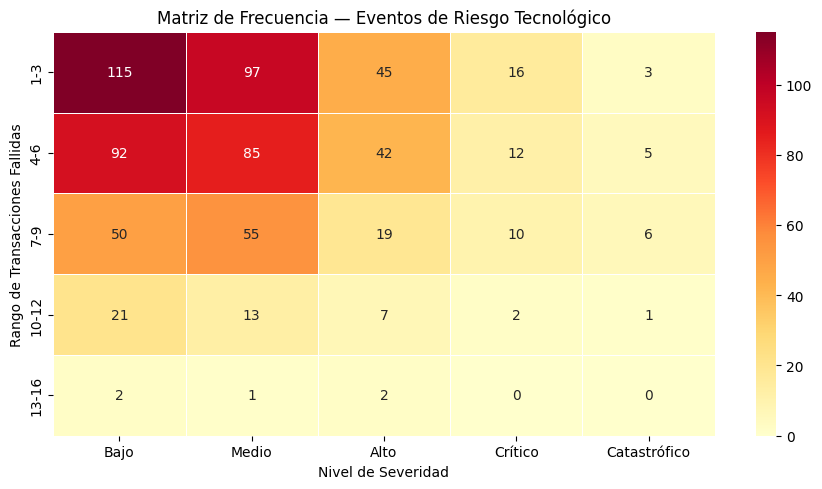

In [6]:
# Niveles de los ejes
niveles_sev  = ['Bajo', 'Medio', 'Alto', 'Crítico', 'Catastrófico']
rangos_freq  = ['1-3', '4-6', '7-9', '10-12', '13-16']

# Construcción de la Matriz de Frecuencia
M_Frec = pd.crosstab(
    XDB['RangoFreq'],
    XDB['Nivel Severidad']
).reindex(index=rangos_freq, columns=niveles_sev, fill_value=0)

print('Matriz de Frecuencia (Conteo de Eventos):')
print('Filas: Rango de Transacciones Fallidas | Columnas: Nivel de Severidad')
display(M_Frec)

# Visualización
plt.figure(figsize=(9, 5))
sns.heatmap(M_Frec, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Matriz de Frecuencia — Eventos de Riesgo Tecnológico')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Rango de Transacciones Fallidas')
plt.tight_layout()
plt.show()

### 3.2 Matriz de Severidad (Pérdida Promedio por Celda)

Matriz de Severidad (Pérdida Promedio en Millones USD por Celda):


/tmp/ipykernel_13440/3649898830.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  M_Sev = XDB.pivot_table(


Nivel Severidad,Bajo,Medio,Alto,Crítico,Catastrófico
RangoFreq,,,,,
1-3,0.5320,1.5637,3.2160,6.8731,13.8261
4-6,0.5411,1.4929,3.3429,6.4244,9.9003
7-9,0.5506,1.5359,3.3544,6.8182,10.6303
10-12,0.5794,1.7739,3.4814,5.5990,11.1083
13-16,0.6018,2.3413,3.3817,0.0000,0.0000


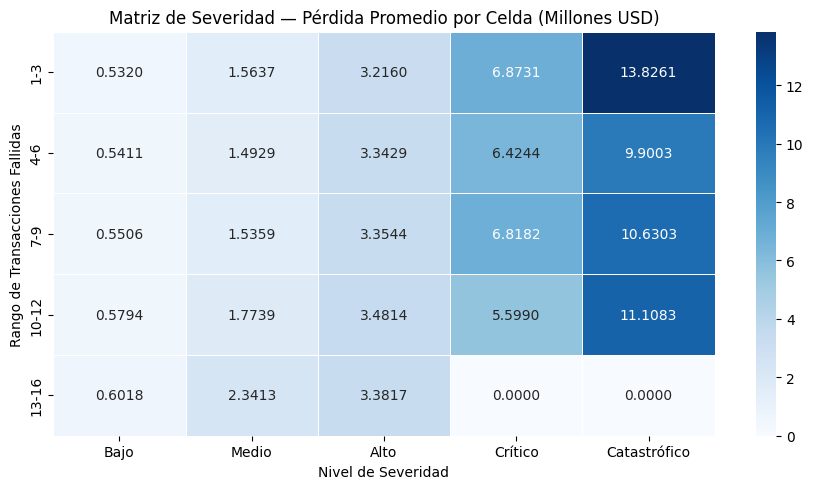

In [8]:
# Construcción de la Matriz de Severidad
M_Sev = XDB.pivot_table(
    values ='Valor Generado Promedio (Millones)',
    index  ='RangoFreq',
    columns='Nivel Severidad',
    aggfunc='mean'
).reindex(index=rangos_freq, columns=niveles_sev)

M_Sev = M_Sev.fillna(0).round(4)

print('Matriz de Severidad (Pérdida Promedio en Millones USD por Celda):')
display(M_Sev)

# Visualización
plt.figure(figsize=(9, 5))
sns.heatmap(M_Sev, annot=True, fmt='.4f', cmap='Blues', linewidths=0.5)
plt.title('Matriz de Severidad — Pérdida Promedio por Celda (Millones USD)')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Rango de Transacciones Fallidas')
plt.tight_layout()
plt.show()

### 3.3 Matriz de Pérdidas Agregadas

Matriz de Pérdidas Agregadas (Frecuencia × Severidad) en Millones USD:


Nivel Severidad,Bajo,Medio,Alto,Crítico,Catastrófico
RangoFreq,,,,,
1-3,61.1800,151.6789,144.7200,109.9696,41.4783
4-6,49.7812,126.8965,140.4018,77.0928,49.5015
7-9,27.5300,84.4745,63.7336,68.1820,63.7818
10-12,12.1674,23.0607,24.3698,11.1980,11.1083
13-16,1.2036,2.3413,6.7634,0.0000,0.0000



Pérdida Agregada Total: 1352.6150 Millones USD


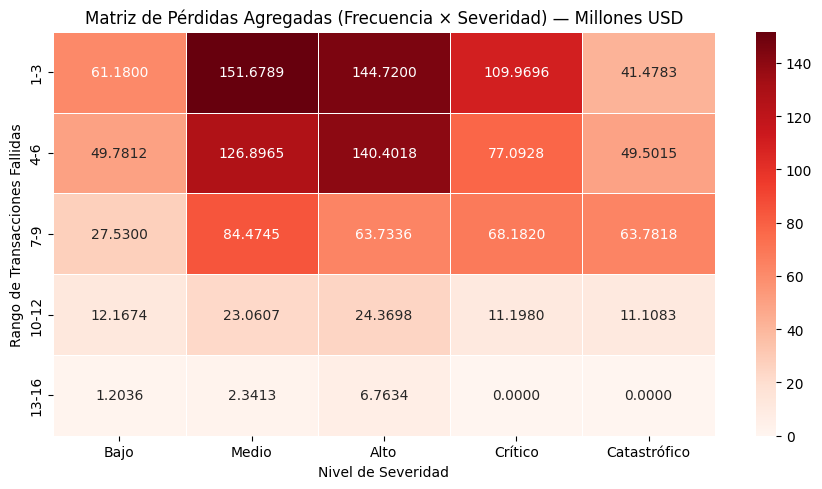

In [9]:
# Pérdida Agregada por celda = Frecuencia (conteo) × Severidad (promedio pérdida)
M_PA = M_Frec * M_Sev
M_PA = M_PA.fillna(0).round(4)

print('Matriz de Pérdidas Agregadas (Frecuencia × Severidad) en Millones USD:')
display(M_PA)

print(f'\nPérdida Agregada Total: {M_PA.values.sum():.4f} Millones USD')

# Visualización
plt.figure(figsize=(9, 5))
sns.heatmap(M_PA, annot=True, fmt='.4f', cmap='Reds', linewidths=0.5)
plt.title('Matriz de Pérdidas Agregadas (Frecuencia × Severidad) — Millones USD')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Rango de Transacciones Fallidas')
plt.tight_layout()
plt.show()

## 4. Matriz de Impacto y Gestión

Matriz de Impacto y Gestión (Pérdida Residual Estimada en Millones USD):
Filas: Nivel de Impacto del Evento | Columnas: Nivel de Control/Gestión Aplicado


,Gestión Bajo,Gestión Medio,Gestión Moderado,Gestión Alto,Gestión Crítico
Impacto Bajo,0.5319,0.5101,0.3930,0.1902,0.0
Impacto Medio,1.5176,1.4554,1.1214,0.5427,0.0
Impacto Alto,3.2403,3.1074,2.3942,1.1588,0.0
Impacto Crítico,6.5320,6.2642,4.8264,2.3360,0.0
Impacto Catastrófico,10.8438,10.3991,8.0123,3.8780,0.0


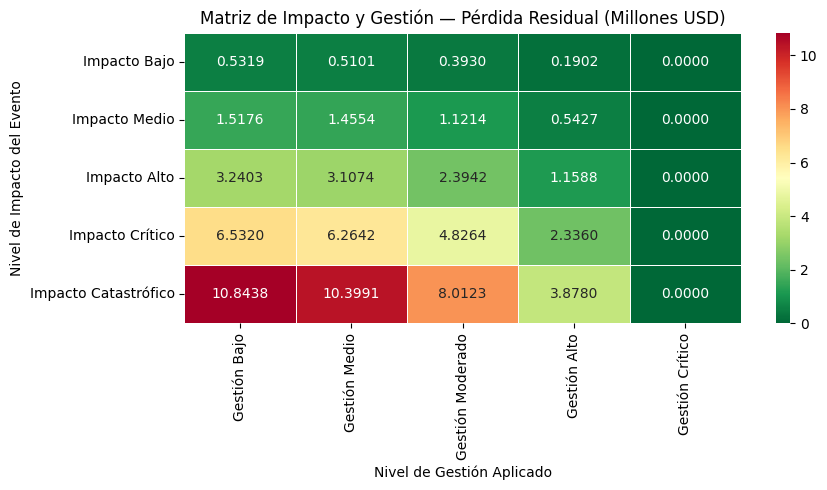

In [10]:
# Tabla de referencia de Riesgos
XR.columns  = ['N', 'Nivel Impacto', 'Descripción Fallo', 'Impacto Operación', 'Impacto Cliente', 'Impacto Financiero', 'Frecuencia']
XR          = XR.dropna(subset=['N'])
XR['N']     = XR['N'].astype(int)

# Tabla de referencia de Gestión
XG.columns  = ['N', 'Nivel Gestión', 'Actividades', 'Costo (KUSD)', 'Desviación']
XG          = XG.dropna(subset=['N'])
XG['N']     = XG['N'].astype(int)

# Niveles de gestión e impacto
niveles_impacto  = XR['Nivel Impacto'].tolist()
niveles_gestion  = XG['Nivel Gestión'].tolist()

# Costos de gestión por nivel (en KUSD)
costos_gestion   = XG.set_index('N')['Costo (KUSD)'].to_dict()
desv_gestion     = XG.set_index('N')['Desviación'].to_dict()

# Pérdidas promedio inherentes por nivel de severidad
perdida_por_sev  = XDB.groupby('Severidad')['Valor Generado Promedio (Millones)'].mean().to_dict()

# Construcción de la Matriz de Impacto y Gestión
# Filas: Nivel de Impacto (Severidad), Columnas: Nivel de Gestión
# Valor en cada celda: Pérdida Residual = Pérdida Inherente - Costo de Gestión (reducción esperada)

matriz_IG = np.zeros((5, 5))
for i in range(5):
    niv_imp = i + 1  # 1 a 5
    for j in range(5):
        niv_ges = j + 1  # 1 a 5
        p_inh   = perdida_por_sev.get(niv_imp, 0)
        costo   = costos_gestion.get(niv_ges, 0)
        # Pérdida residual = pérdida inherente reducida por la eficacia del control
        # Eficacia = costo/max_costo (gestión normalizada sobre pérdida)
        eficacia = costo / max(costos_gestion.values())
        p_res    = p_inh * (1 - eficacia)
        if p_res < 0:
            p_res = 0
        matriz_IG[i, j] = round(p_res, 4)

M_IG = pd.DataFrame(
    matriz_IG,
    index  = [f'Impacto {n}' for n in niveles_impacto],
    columns= [f'Gestión {n}' for n in niveles_gestion]
)

print('Matriz de Impacto y Gestión (Pérdida Residual Estimada en Millones USD):')
print('Filas: Nivel de Impacto del Evento | Columnas: Nivel de Control/Gestión Aplicado')
display(M_IG)

# Visualización
plt.figure(figsize=(9, 5))
sns.heatmap(M_IG, annot=True, fmt='.4f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Matriz de Impacto y Gestión — Pérdida Residual (Millones USD)')
plt.xlabel('Nivel de Gestión Aplicado')
plt.ylabel('Nivel de Impacto del Evento')
plt.tight_layout()
plt.show()

## 5. Estimación Cuantitativa
### 5.1 Función de caracterización de pérdidas

In [11]:
def Caracterizacion_Perdidas(X, titulo='Pérdidas'):
    plt.figure(figsize=(10, 5))
    sns.histplot(X, bins=10, kde=True)
    plt.xlabel(titulo)
    plt.grid()
    plt.show()

    NI     = 10
    counts, bin_edges = np.histogram(X, bins=NI)
    XC     = (bin_edges[:-1] + bin_edges[1:]) / 2
    prob   = counts / np.sum(counts)

    u      = np.sum(XC * prob)
    var    = np.sum(prob * (XC - u)**2)
    sigma  = np.sqrt(var)
    CAs    = np.sum(prob * (XC - u)**3) / sigma**3
    kur    = (np.sum(prob * (XC - u)**4) / sigma**4) - 3

    return u, var, sigma, CAs, kur

### 5.2 Pérdida Esperada (PE) — Riesgo Inherente

===== RIESGO INHERENTE =====


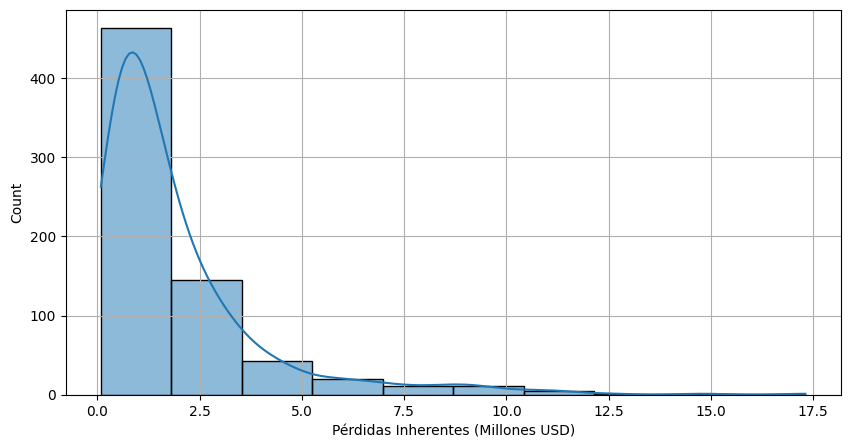

Pérdida Esperada (PE) Inherente:   2.0369 Millones USD
Desviación estándar:               2.0993 Millones USD
Coeficiente de Asimetría:          2.8515
Curtosis:                          9.8796


In [14]:
# Pérdidas No Gestionadas
perdidas_inh = np.array(XDB['Valor Generado Promedio (Millones)'])
perdidas_inh = perdidas_inh[perdidas_inh > 0]  # Solo pérdidas positivas

print('===== RIESGO INHERENTE =====')
u_inh, var_inh, sigma_inh, CAs_inh, kur_inh = Caracterizacion_Perdidas(perdidas_inh, 'Pérdidas Inherentes (Millones USD)')

PE_inh = u_inh
print(f'Pérdida Esperada (PE) Inherente:   {PE_inh:.4f} Millones USD')
print(f'Desviación estándar:               {sigma_inh:.4f} Millones USD')
print(f'Coeficiente de Asimetría:          {CAs_inh:.4f}')
print(f'Curtosis:                          {kur_inh:.4f}')

### 5.3 Pérdida Esperada (PE) — Riesgo Residual

===== RIESGO RESIDUAL (Pérdidas Gestionadas) =====


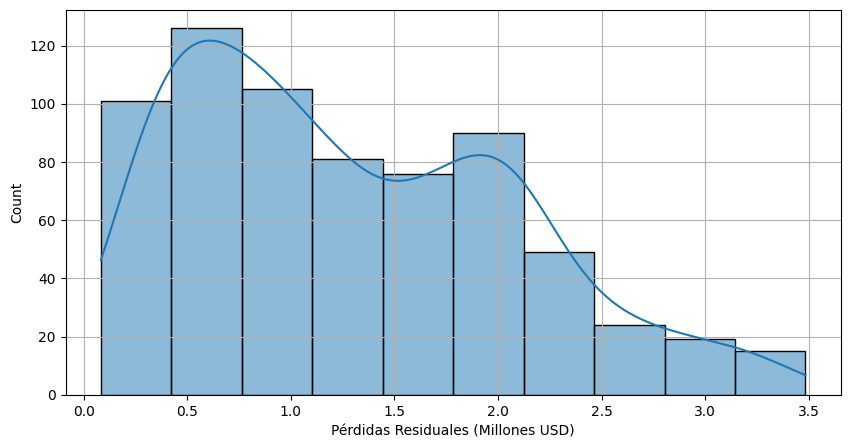

Pérdida Esperada (PE) Residual:    1.2852 Millones USD
Desviación estándar:               0.8000 Millones USD
Coeficiente de Asimetría:          0.5641
Curtosis:                          -0.4962


In [15]:
# Pérdidas Gestionadas
# Nivel de gestión por severidad: se asigna el nivel de gestión igual al nivel de severidad
XDB['NivGestion'] = XDB['Severidad'].copy()

# Factor de reducción por nivel de gestión
max_costo = max(costos_gestion.values())

def factor_reduccion(nivel):
    return costos_gestion.get(nivel, 0) / max_costo

XDB['Factor Reduccion'] = XDB['NivGestion'].apply(factor_reduccion)
XDB['Perdida Residual'] = XDB['Valor Generado Promedio (Millones)'] * (1 - XDB['Factor Reduccion'])
XDB['Perdida Residual'] = XDB['Perdida Residual'].clip(lower=0)

perdidas_res = np.array(XDB['Perdida Residual'])
perdidas_res = perdidas_res[perdidas_res > 0]

print('===== RIESGO RESIDUAL (Pérdidas Gestionadas) =====')
u_res, var_res, sigma_res, CAs_res, kur_res = Caracterizacion_Perdidas(perdidas_res, 'Pérdidas Residuales (Millones USD)')

PE_res = u_res
print(f'Pérdida Esperada (PE) Residual:    {PE_res:.4f} Millones USD')
print(f'Desviación estándar:               {sigma_res:.4f} Millones USD')
print(f'Coeficiente de Asimetría:          {CAs_res:.4f}')
print(f'Curtosis:                          {kur_res:.4f}')

### 5.4 Operational Value at Risk (OpVaR) al 99.9%

===== OPERATIONAL VALUE AT RISK — OpVaR al 99.9% =====

Riesgo Inherente (No Gestionado):
  Pérdida Esperada (PE):  2.0369  Millones USD
  OpVaR al 99.9%:         15.5486  Millones USD

Riesgo Residual (Gestionado):
  Pérdida Esperada (PE):  1.2852  Millones USD
  OpVaR al 99.9%:         3.4265  Millones USD

Reducción por Gestión:
  Reducción en PE:        0.7517  Millones USD (36.90%)
  Reducción en OpVaR:     12.1221  Millones USD (77.96%)


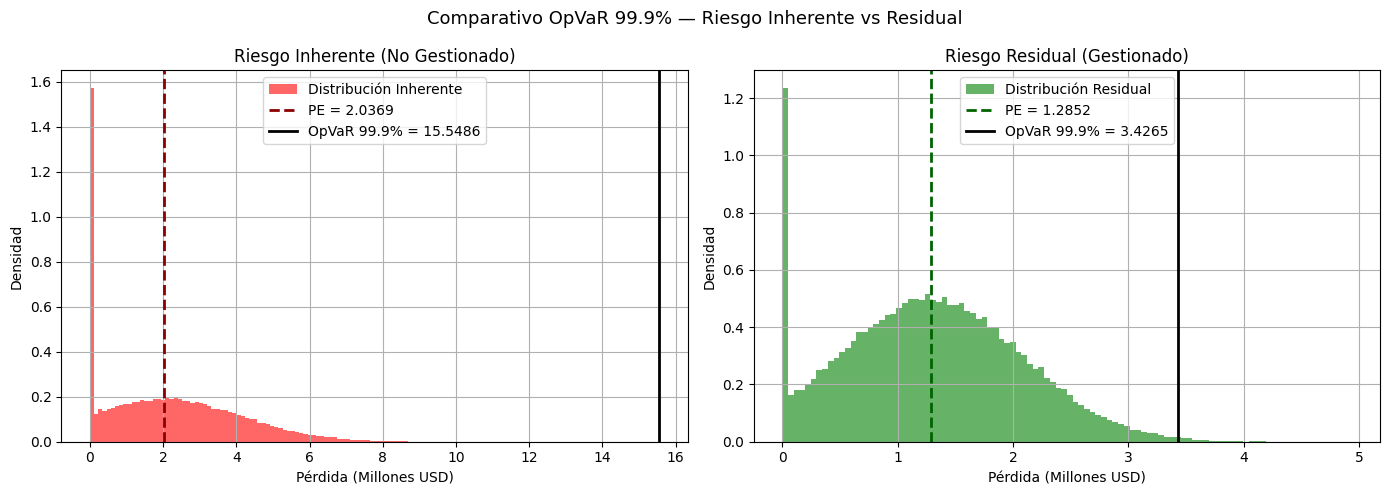

In [19]:
OpVaR_inh = np.percentile(perdidas_inh, 99.9)
OpVaR_res = np.percentile(perdidas_res, 99.9)

print('===== OPERATIONAL VALUE AT RISK — OpVaR al 99.9% =====')
print()
print(f'Riesgo Inherente (No Gestionado):')
print(f'  Pérdida Esperada (PE):  {PE_inh:.4f}  Millones USD')
print(f'  OpVaR al 99.9%:         {OpVaR_inh:.4f}  Millones USD')
print()
print(f'Riesgo Residual (Gestionado):')
print(f'  Pérdida Esperada (PE):  {PE_res:.4f}  Millones USD')
print(f'  OpVaR al 99.9%:         {OpVaR_res:.4f}  Millones USD')
print()
print(f'Reducción por Gestión:')
print(f'  Reducción en PE:        {PE_inh - PE_res:.4f}  Millones USD ({(1 - PE_res/PE_inh)*100:.2f}%)')
print(f'  Reducción en OpVaR:     {OpVaR_inh - OpVaR_res:.4f}  Millones USD ({(1 - OpVaR_res/OpVaR_inh)*100:.2f}%)')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sim_inh, bins=100, density=True, alpha=0.6, color='red', label='Distribución Inherente')
axes[0].axvline(PE_inh,    color='darkred',  linestyle='--', linewidth=2, label=f'PE = {PE_inh:.4f}')
axes[0].axvline(OpVaR_inh, color='black',    linestyle='-',  linewidth=2, label=f'OpVaR 99.9% = {OpVaR_inh:.4f}')
axes[0].set_title('Riesgo Inherente (No Gestionado)')
axes[0].set_xlabel('Pérdida (Millones USD)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(sim_res, bins=100, density=True, alpha=0.6, color='green', label='Distribución Residual')
axes[1].axvline(PE_res,    color='darkgreen', linestyle='--', linewidth=2, label=f'PE = {PE_res:.4f}')
axes[1].axvline(OpVaR_res, color='black',     linestyle='-',  linewidth=2, label=f'OpVaR 99.9% = {OpVaR_res:.4f}')
axes[1].set_title('Riesgo Residual (Gestionado)')
axes[1].set_xlabel('Pérdida (Millones USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Comparativo OpVaR 99.9% — Riesgo Inherente vs Residual', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Tabla Resumen — Comparativo Inherente vs Residual

In [17]:
# Tabla resumen cuantitativa
Tabla_comp = np.column_stack((
    [PE_inh,    PE_res],
    [var_inh,   var_res],
    [sigma_inh, sigma_res],
    [CAs_inh,   CAs_res],
    [kur_inh,   kur_res],
    [OpVaR_inh, OpVaR_res]
))

df_comp = pd.DataFrame(
    Tabla_comp,
    columns=['PE (Media)', 'Varianza', 'Desviación', 'Asimetría', 'Curtosis', 'OpVaR 99.9%'],
    index  =['Riesgo Inherente', 'Riesgo Residual']
)

print('Tabla Resumen — Estimación Cuantitativa del Riesgo Operacional (Millones USD):')
display(df_comp.round(4))

Tabla Resumen — Estimación Cuantitativa del Riesgo Operacional (Millones USD):


,PE (Media),Varianza,Desviación,Asimetría,Curtosis,OpVaR 99.9%
Riesgo Inherente,2.0369,4.407,2.0993,2.8515,9.8796,8.4934
Riesgo Residual,1.2852,0.640,0.8000,0.5641,-0.4962,3.6996


## 6. Herramienta de Auditoría — Filtro Dinámico por Celda de la Matriz

In [22]:
def auditoria_celda(rango_freq, nivel_sev):
    filtro = (
        (XDB['RangoFreq']       == rango_freq) &
        (XDB['Nivel Severidad'] == nivel_sev)
    )

    resultado = XDB[filtro][[
        'Fechas',
        'Transacciones Diarias',
        'Transacciones Fallidas',
        'Valor Transado (millones)',
        'Valor Generado Promedio (Millones)',
        'Nivel Severidad',
        'Descripción Evento'
    ]].copy().reset_index(drop=True)

    n_eventos        = len(resultado)
    perdida_total    = resultado['Valor Generado Promedio (Millones)'].sum()
    perdida_promedio = resultado['Valor Generado Promedio (Millones)'].mean() if n_eventos > 0 else 0

    print('=' * 70)
    print(f'HERRAMIENTA DE AUDITORÍA — FILTRO POR CELDA DE MATRIZ')
    print('=' * 70)
    print(f'  Rango de Transacciones Fallidas : {rango_freq}')
    print(f'  Nivel de Severidad              : {nivel_sev}')
    print(f'  Número de eventos               : {n_eventos}')
    print(f'  Pérdida Total (Millones USD)    : {perdida_total:.4f}')
    print(f'  Pérdida Promedio (Millones USD) : {perdida_promedio:.4f}')
    print('=' * 70)

    if n_eventos == 0:
        print('No se encontraron eventos para esta combinación.')
    else:
        display(resultado)

    return resultado


# Ejemplo de uso 1: Celda de mayor pérdida agregada
print('\n--- EJEMPLO 1: Rango 7-9 Transacciones Fallidas | Severidad Catastrófico ---')
df_auditoria_1 = auditoria_celda('7-9', 'Catastrófico')


--- EJEMPLO 1: Rango 7-9 Transacciones Fallidas | Severidad Catastrófico ---
HERRAMIENTA DE AUDITORÍA — FILTRO POR CELDA DE MATRIZ
  Rango de Transacciones Fallidas : 7-9
  Nivel de Severidad              : Catastrófico
  Número de eventos               : 6
  Pérdida Total (Millones USD)    : 63.7817
  Pérdida Promedio (Millones USD) : 10.6303


,Fechas,Transacciones Diarias,Transacciones Fallidas,Valor Transado (millones),Valor Generado Promedio (Millones),Nivel Severidad,Descripción Evento
0,2009-01-08,90,8,36.4063,12.4245,Catastrófico,"Caída total del sistema por más de 24 horas, p..."
1,2009-07-22,125,7,16.8511,11.2667,Catastrófico,"Caída total del sistema por más de 24 horas, p..."
2,2009-08-07,95,9,26.0267,9.1223,Catastrófico,"Caída total del sistema por más de 24 horas, p..."
3,2009-10-26,105,8,22.9937,10.4570,Catastrófico,"Caída total del sistema por más de 24 horas, p..."
4,2009-11-26,100,7,13.7461,10.6269,Catastrófico,"Caída total del sistema por más de 24 horas, p..."
5,2011-03-02,95,8,24.4764,9.8843,Catastrófico,"Caída total del sistema por más de 24 horas, p..."


## 7. Análisis de Resultados

La construcción integrada de la arquitectura de matrices permite estructurar y cuantificar el riesgo operacional de los canales electrónicos en tres dimensiones complementarias: frecuencia, severidad y pérdida agregada.

La **Matriz de Frecuencia** revela que la concentración de eventos se encuentra en los rangos de menor magnitud de transacciones fallidas (1-3 y 4-6), con severidades principalmente Baja y Media.

La **Matriz de Severidad** muestra que las pérdidas promedio por evento aumentan considerablemente al escalar en nivel de severidad, siendo los eventos Catastróficos los que registran pérdidas unitarias notablemente superiores, incluso cuando su frecuencia es muy baja.

La **Matriz de Pérdidas Agregadas** combina ambas dimensiones, identificando las celdas de mayor exposición económica acumulada. Las celdas con severidad Alta y Crítico con frecuencias intermedias concentran una proporción relevante del riesgo total, lo que orienta los esfuerzos de control hacia esos segmentos.

La **Matriz de Impacto y Gestión** evidencia cómo la aplicación progresiva de niveles de gestión más robustos reduce sistemáticamente la pérdida residual esperada, siendo el nivel Crítico de gestión el que mayor reducción proporciona sobre eventos de alta severidad.

Desde el punto de vista cuantitativo, la comparación entre Riesgo Inherente y Riesgo Residual muestra que la aplicación de controles logra reducir tanto la Pérdida Esperada (PE) como el OpVaR al 99.9%, lo que confirma la eficacia de la gestión sobre la exposición económica en escenarios extremos.

## 8. Conclusiones

Las matrices construidas ofrecen una visión multidimensional del riesgo que facilita la priorización de controles, la asignación eficiente de recursos de gestión y la cuantificación de la exposición económica bajo dos escenarios: sin gestión (Riesgo Inherente) y con gestión aplicada (Riesgo Residual).

El OpVaR al 99.9% constituye la medida de capital regulatorio más relevante para la entidad, ya que captura el impacto de los eventos más extremos que, aunque poco frecuentes, pueden comprometer la sostenibilidad operativa. La herramienta de auditoría por filtro dinámico complementa el análisis al permitir desagregar cualquier celda de la matriz hasta el nivel de evento individual, facilitando las labores de revisión interna y control.